In [152]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import random
import json

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report,confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_auc_score

import tensorflow as tf
from tensorflow import keras
from keras.models import Sequential
from keras.layers import Dense,Dropout

from keras.models import load_model

In [154]:
df = pd.read_excel('/Users/skipper/university/8semester/SUML/final_project/lending_club_loan_info_ex.xlsx')

<Axes: xlabel='loan_status', ylabel='count'>

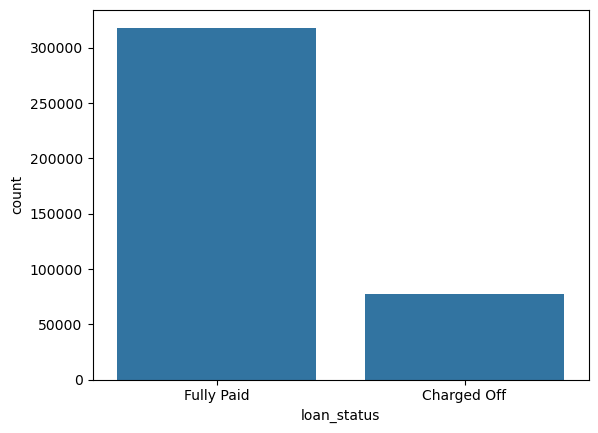

In [156]:
sns.countplot(x='loan_status',data=df)

In [158]:
df.groupby('loan_status')['loan_amnt'].describe()

,count,unique,top,freq
loan_status,,,,
Charged Off,77662,1298,10000.0,4830
Fully Paid,318296,1393,10000.0,22833


In [160]:
df['grade'].unique()

array(['B', 'A', 'C', 'E', 'D', 'F', 'G', nan], dtype=object)

In [162]:
df['sub_grade'].unique()

array(['B5', 'B3', 'A2', 'C5', 'C3', 'A1', 'B2', 'B4', 'C1', 'A5', 'E4',
       'A4', 'A3', 'D1', 'C2', 'B1', 'D3', 'D5', 'D2', 'E1', 'E2', 'E5',
       'F4', 'E3', 'D4', 'G1', 'F5', 'G2', 'C4', 'F1', 'F3', 'G5', 'G4',
       'F2', 'G3', nan], dtype=object)

<Axes: xlabel='grade', ylabel='count'>

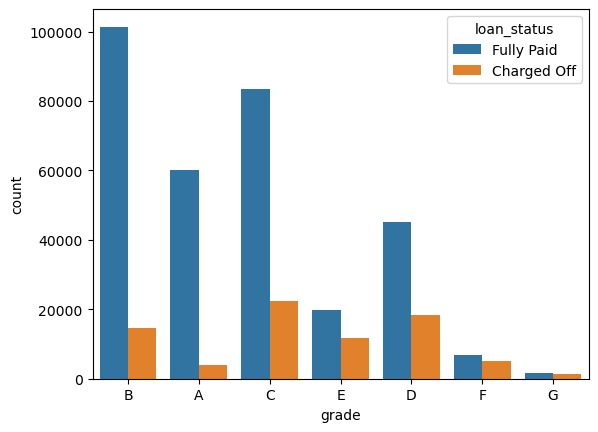

In [164]:
sns.countplot(x='grade',data=df,hue='loan_status')

<Axes: xlabel='sub_grade', ylabel='count'>

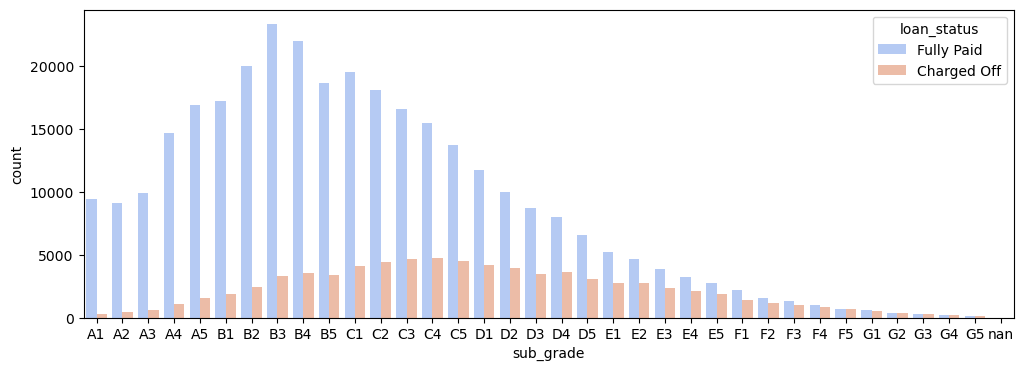

In [166]:
plt.figure(figsize=(12,4))
df['sub_grade'] = df['sub_grade'].astype(str)
subgrade_order = sorted(df['sub_grade'].unique())
sns.countplot(x='sub_grade',data=df,order=subgrade_order,palette='coolwarm', hue='loan_status')

<Axes: xlabel='sub_grade', ylabel='count'>

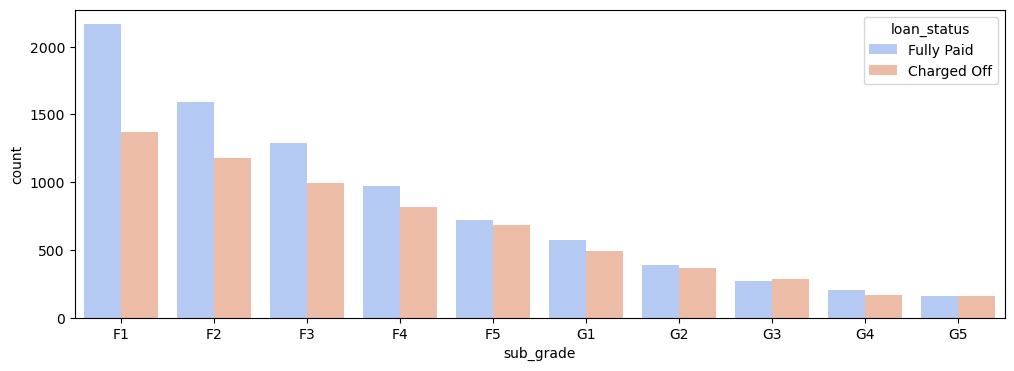

In [168]:
f_and_g = df[(df['grade']=='G') | (df['grade']=='F')]

plt.figure(figsize=(12,4))
subgrade_order = sorted(f_and_g['sub_grade'].unique())
sns.countplot(x='sub_grade',data=f_and_g,order=subgrade_order,palette='coolwarm', hue='loan_status')

In [170]:
df['loan_repaid'] = df['loan_status'].map({'Fully Paid' :1, 'Charged Off' :0})

In [172]:
df[['loan_repaid','loan_status']]

,loan_repaid,loan_status
0,1.0,Fully Paid
1,1.0,Fully Paid
2,1.0,Fully Paid
3,0.0,Charged Off
4,1.0,Fully Paid
...,...,...
396027,1.0,Fully Paid
396028,1.0,Fully Paid
396029,1.0,Fully Paid
396030,1.0,Fully Paid


<Axes: >

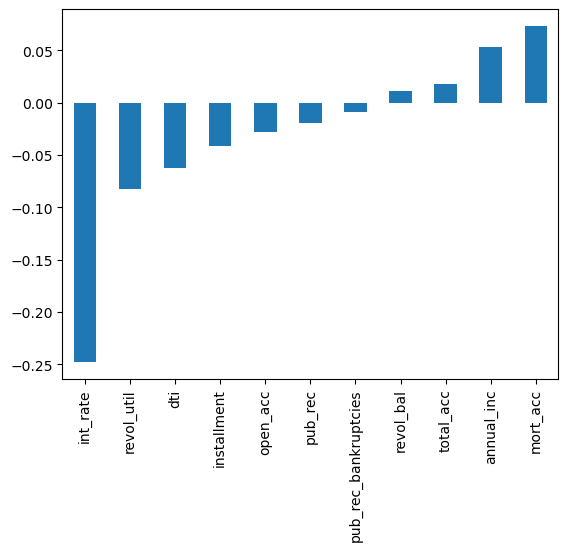

In [174]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()['loan_repaid'].sort_values().drop('loan_repaid').plot(kind='bar')

In [176]:
100 * df.isnull().sum() / len(df)

loan_amnt               0.000000
term                    0.001263
int_rate                0.018685
installment             0.018685
grade                   0.018685
sub_grade               0.000000
emp_title               5.807359
emp_length              4.639777
home_ownership          0.018685
annual_inc              0.018685
verification_status     0.018685
issue_d                 0.018685
loan_status             0.018685
purpose                 0.018685
title                   0.462084
dti                     0.019948
earliest_cr_line        0.019948
open_acc                0.019948
pub_rec                 0.019948
revol_bal               0.019948
revol_util              0.089639
total_acc               0.019948
initial_list_status     0.019948
application_type        0.019948
mort_acc                9.557309
pub_rec_bankruptcies    0.154785
address                 0.019948
loan_repaid             0.018685
dtype: float64

In [178]:
df = df.drop('emp_title',axis=1)

In [180]:
sorted(df['emp_length'].dropna().unique())

['1 year',
 '10+ years',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '< 1 year']

In [182]:
emp_length_order = ['< 1 year',
 '1 year',
 '2 years',
 '3 years',
 '4 years',
 '5 years',
 '6 years',
 '7 years',
 '8 years',
 '9 years',
 '10+ years'
]

<Axes: xlabel='emp_length', ylabel='count'>

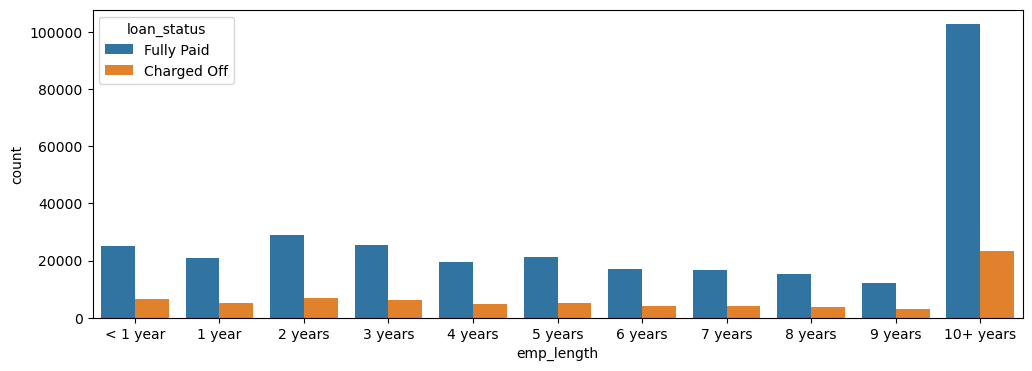

In [184]:
plt.figure(figsize=(12,4))
sns.countplot(x='emp_length',data=df,order=emp_length_order, hue='loan_status')

In [186]:
emp_co = df[df['loan_status']=='Charged Off'].groupby('emp_length').count()['loan_status']

In [188]:
emp_fp = df[df['loan_status']=='Fully Paid'].groupby('emp_length').count()['loan_status']

In [190]:
emp_len = emp_co/(emp_co+emp_fp)

<Axes: xlabel='emp_length'>

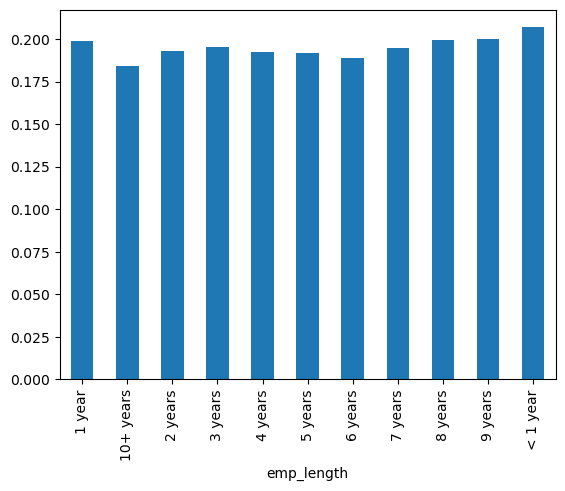

In [192]:
emp_len.plot(kind='bar')

In [194]:
df = df.drop('emp_length',axis=1)

In [196]:
df = df.drop('title',axis=1)

In [198]:
df['mort_acc'].value_counts()

mort_acc
0.0     139759
1.0      60407
2.0      49940
3.0      38041
4.0      27882
5.0      18191
6.0      11068
7.0       6052
8.0       3120
9.0       1656
10.0       865
11.0       479
12.0       264
13.0       146
14.0       107
15.0        61
16.0        37
17.0        22
18.0        18
19.0        15
20.0        13
24.0        10
22.0         7
21.0         4
25.0         4
27.0         3
32.0         2
31.0         2
23.0         2
26.0         2
28.0         1
30.0         1
34.0         1
Name: count, dtype: int64

In [200]:
numeric_df = df.select_dtypes(include=['number'])
numeric_df.corr()['mort_acc'].sort_values()

int_rate               -0.082586
dti                    -0.025439
revol_util              0.007515
pub_rec                 0.011555
pub_rec_bankruptcies    0.027238
loan_repaid             0.073121
open_acc                0.109211
installment             0.193714
revol_bal               0.194931
annual_inc              0.236325
total_acc               0.381085
mort_acc                1.000000
Name: mort_acc, dtype: float64

In [202]:
total_acc_avg = numeric_df.groupby('total_acc').mean()['mort_acc']

In [204]:
def fill_mort_acc(total_acc, mort_acc):
    if np.isnan(mort_acc) and not np.isnan(total_acc):
        return total_acc_avg[total_acc]
    else:
        return mort_acc

In [206]:
df['mort_acc'] = numeric_df.apply(lambda x: fill_mort_acc(x['total_acc'],x['mort_acc']),axis=1)

In [208]:
df.isnull().sum()

loan_amnt                 0
term                      5
int_rate                 74
installment              74
grade                    74
sub_grade                 0
home_ownership           74
annual_inc               74
verification_status      74
issue_d                  74
loan_status              74
purpose                  74
dti                      79
earliest_cr_line         79
open_acc                 79
pub_rec                  79
revol_bal                79
revol_util              355
total_acc                79
initial_list_status      79
application_type         79
mort_acc                 79
pub_rec_bankruptcies    613
address                  79
loan_repaid              74
dtype: int64

In [210]:
df = df.dropna()

In [212]:
df.isnull().sum()

loan_amnt               0
term                    0
int_rate                0
installment             0
grade                   0
sub_grade               0
home_ownership          0
annual_inc              0
verification_status     0
issue_d                 0
loan_status             0
purpose                 0
dti                     0
earliest_cr_line        0
open_acc                0
pub_rec                 0
revol_bal               0
revol_util              0
total_acc               0
initial_list_status     0
application_type        0
mort_acc                0
pub_rec_bankruptcies    0
address                 0
loan_repaid             0
dtype: int64

In [214]:
df.select_dtypes(['object']).columns

Index(['loan_amnt', 'term', 'grade', 'sub_grade', 'home_ownership',
       'verification_status', 'issue_d', 'loan_status', 'purpose',
       'earliest_cr_line', 'initial_list_status', 'application_type',
       'address'],
      dtype='object')

In [216]:
df['term'].value_counts()

term
36 months    301184
60 months     93959
Name: count, dtype: int64

In [218]:
df['term'] = df['term'].apply(lambda term: int(term[:3]))

In [220]:
df['term'].value_counts()

term
36    301184
60     93959
Name: count, dtype: int64

In [222]:
df = df.drop('grade',axis=1)

In [224]:
dummies = pd.get_dummies(df['sub_grade'],drop_first=True)

df = pd.concat([df.drop('sub_grade',axis=1),dummies],axis=1)

In [226]:
dummies = pd.get_dummies(df[['verification_status','application_type','initial_list_status','purpose']],drop_first=True)

df = pd.concat([df.drop(['verification_status','application_type','initial_list_status','purpose'],axis=1),dummies],axis=1)

In [228]:
df['home_ownership'] = df['home_ownership'].replace(['NONE','ANY'],'OTHER')

In [230]:
dummies = pd.get_dummies(df['home_ownership'],drop_first=True)

df = pd.concat([df.drop('home_ownership',axis=1),dummies],axis=1)

In [232]:
df['zip_code'] = df['address'].apply(lambda address:address[-5:])

In [234]:
dummies = pd.get_dummies(df['zip_code'],drop_first=True)

df = pd.concat([df.drop('zip_code',axis=1),dummies],axis=1)

In [236]:
df = df.drop('address',axis=1)

In [238]:
df = df.drop('issue_d',axis=1)

In [240]:
df['earliest_cr_line'] = df['earliest_cr_line'].apply(lambda date: int(date[-4:]))

In [242]:
df.head()

,loan_amnt,term,int_rate,installment,annual_inc,loan_status,dti,earliest_cr_line,open_acc,pub_rec,...,RENT,05113,11650,22690,29597,30723,48052,70466,86630,93700
0,8000.0,36,11.99,265.68,65000.0,Fully Paid,22.05,2004,17.0,0.0,...,False,True,False,False,False,False,False,False,False,False
1,15600.0,36,10.49,506.97,43057.0,Fully Paid,12.79,2007,13.0,0.0,...,True,True,False,False,False,False,False,False,False,False
2,7200.0,36,6.49,220.65,54000.0,Fully Paid,2.60,2006,6.0,0.0,...,True,False,False,False,False,False,False,False,False,False
3,24375.0,60,17.27,609.33,55000.0,Charged Off,33.95,1999,13.0,0.0,...,False,False,True,False,False,False,False,False,False,False
4,20000.0,36,13.33,677.07,86788.0,Fully Paid,16.31,2005,8.0,0.0,...,False,False,False,False,False,True,False,False,False,False


In [244]:
df = df.drop('loan_status',axis=1)

In [246]:
X = df.drop('loan_repaid',axis=1).values

In [248]:
y = df['loan_repaid'].values

In [250]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=101)

In [252]:
scaler = MinMaxScaler()

In [254]:
X_train = scaler.fit_transform(X_train)

In [256]:
X_test = scaler.transform(X_test)

In [274]:
scaler_data = {
    "min": scaler.data_min_.tolist(),
    "max": scaler.data_max_.tolist()
}

# Save to a JSON file
with open("/Users/skipper/university/8semester/SUML/final_project/new_model/scaler_params.json", "w") as f:
    json.dump(scaler_data, f)

print(scaler_data)

{'min': [500.0, 36.0, 5.32, 16.08, 0.0, 0.0, 1944.0, 1.0, 0.0, 0.0, 0.0, 2.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0, 0.0], 'max': [40000.0, 60.0, 30.99, 1533.81, 8706582.0, 9999.0, 2013.0, 90.0, 86.0, 1743266.0, 892.3, 150.0, 34.0, 8.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0]}


In [270]:
len(scaler.data_min_.tolist())

78

In [272]:
len(scaler.data_max_.tolist())

78

In [108]:
model = Sequential()
model.add(Dense(78,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(39,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(19,activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(units=1,activation='sigmoid'))

In [110]:
model.compile(loss='binary_crossentropy',optimizer='adam')

In [112]:
X_train.shape

(316114, 78)

In [114]:
model.fit(x=X_train,y=y_train,epochs=25,batch_size=256,validation_data=(X_test,y_test))

Epoch 1/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 2s 1ms/step - loss: 0.3569 - val_loss: 0.2645
Epoch 2/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 900us/step - loss: 0.2674 - val_loss: 0.2608
Epoch 3/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - loss: 0.2634 - val_loss: 0.2610
Epoch 4/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 922us/step - loss: 0.2634 - val_loss: 0.2597
Epoch 5/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 911us/step - loss: 0.2599 - val_loss: 0.2594
Epoch 6/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - loss: 0.2592 - val_loss: 0.2596
Epoch 7/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 910us/step - loss: 0.2614 - val_loss: 0.2590
Epoch 8/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 914us/step - loss: 0.2591 - val_loss: 0.2595
Epoch 9/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 1ms/step - loss: 0.2603 - val_loss: 0.2591
Epoch 10/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 939us/step - loss: 0.2603 - val_loss: 0.2589
Epoch 11/25
1235/1235 ━━━━━━━━━━━━━━━━━━━━ 1s 915us/step - loss: 0.2572 - val_loss: 0.2592
Epoch 12/25


In [116]:
losses = pd.DataFrame(model.history.history)

<Axes: >

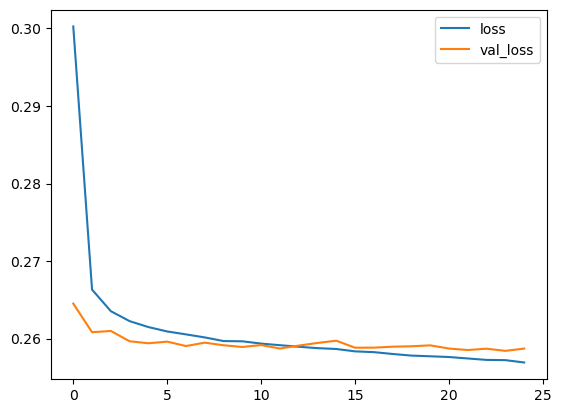

In [118]:
losses.plot()

In [120]:
predictions = (model.predict(X_test) > 0.5).astype("int32")

2470/2470 ━━━━━━━━━━━━━━━━━━━━ 1s 250us/step


In [122]:
print(classification_report(y_test, predictions))

              precision    recall  f1-score   support

         0.0       0.97      0.45      0.61     15498
         1.0       0.88      1.00      0.94     63531

    accuracy                           0.89     79029
   macro avg       0.93      0.72      0.77     79029
weighted avg       0.90      0.89      0.87     79029



In [124]:
#Calculating probabilities without threshold
probabilities = model.predict(X_test)

2470/2470 ━━━━━━━━━━━━━━━━━━━━ 1s 260us/step


In [126]:
#Calculating ROC_AUC
roc_auc = roc_auc_score(y_test, probabilities)

In [128]:
print(f"ROC AUC Score: {roc_auc}")

ROC AUC Score: 0.9035524295010636


In [130]:
df['loan_repaid'].value_counts()

loan_repaid
1.0    317631
0.0     77512
Name: count, dtype: int64

In [132]:
317631/len(df)

0.8038381041800057

In [134]:
confusion_matrix(y_test, predictions)

array([[ 6898,  8600],
       [  191, 63340]])

In [136]:

random.seed(101)
random_ind = random.randint(0,len(df))

new_customer = df.drop('loan_repaid',axis=1).iloc[random_ind]
new_customer

loan_amnt       9600.0
term                36
int_rate         11.99
installment     318.82
annual_inc     90000.0
                ...   
30723            False
48052            False
70466            False
86630            False
93700            False
Name: 305379, Length: 78, dtype: object

In [138]:
print(new_customer.transpose().to_string(header=False))

loan_amnt                               9600.0
term                                        36
int_rate                                 11.99
installment                             318.82
annual_inc                             90000.0
dti                                       29.6
earliest_cr_line                          2001
open_acc                                  30.0
pub_rec                                    0.0
revol_bal                              17620.0
revol_util                                95.2
total_acc                                 58.0
mort_acc                                   3.0
pub_rec_bankruptcies                       0.0
A2                                       False
A3                                       False
A4                                       False
A5                                       False
B1                                       False
B2                                       False
B3                                        True
B4           

In [140]:
df.head()['loan_repaid']

0    1.0
1    1.0
2    1.0
3    0.0
4    1.0
Name: loan_repaid, dtype: float64

In [142]:
new_customer = scaler.transform(new_customer.values.reshape(1,78))

In [144]:
(model.predict(new_customer)>0.5).astype("int32")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 17ms/step


array([[1]], dtype=int32)

In [146]:
df.iloc[random_ind]['loan_repaid']

1.0

In [146]:
model.save('/Users/skipper/university/8semester/SUML/final_project/new_model/loan_model.keras')

In [171]:
new_model = load_model('/Users/skipper/university/8semester/SUML/final_project/new_model/loan_model.keras')

In [173]:
(new_model.predict(new_customer)>0.5).astype("int32")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


array([[1]], dtype=int32)